# Explainable ML for Financial Fraud Detection (SHAP + LIME)

This notebook provides a dissertation-friendly, step-by-step fraud detection pipeline using:
- Logistic Regression
- Random Forest
- Artificial Neural Network (ANN)
- SHAP and LIME explainability

> Update `DATA_PATH` in Section 2 if your dataset location is different.


In [ ]:
pip install pandas numpy matplotlib scikit-learn imbalanced-learn tensorflow shap lime


Note: you may need to restart the kernel to use updated packages.


In [ ]:
# ==========================
# SECTION 1: IMPORT LIBRARIES
# ==========================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, auc
)

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import shap
from lime.lime_tabular import LimeTabularExplainer

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)


## Section 2: Load Dataset
Loads CSV data and prints key checks (shape, columns, data types, missing values).


In [5]:
# ==========================
# SECTION 2: LOAD DATASET
# ==========================

# Change this path if needed
DATA_PATH = r"D:/Dissertation/data/creditcard.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print("First 5 rows:")
print(df.head())
print("Data types:")
print(df.dtypes)
print("Missing values per column:")
print(df.isnull().sum())


Dataset shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
First 5 rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.24

## Section 3: Exploratory Data Analysis (EDA)
Covers class imbalance, distribution plots, correlation heatmap, and outlier checks.


Basic summary:
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
std    1.380247e+00  1.3322

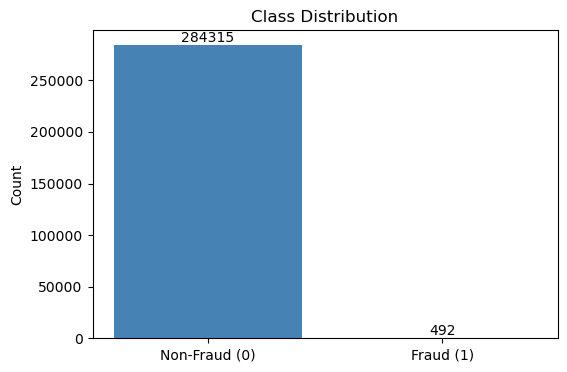

Numerical columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


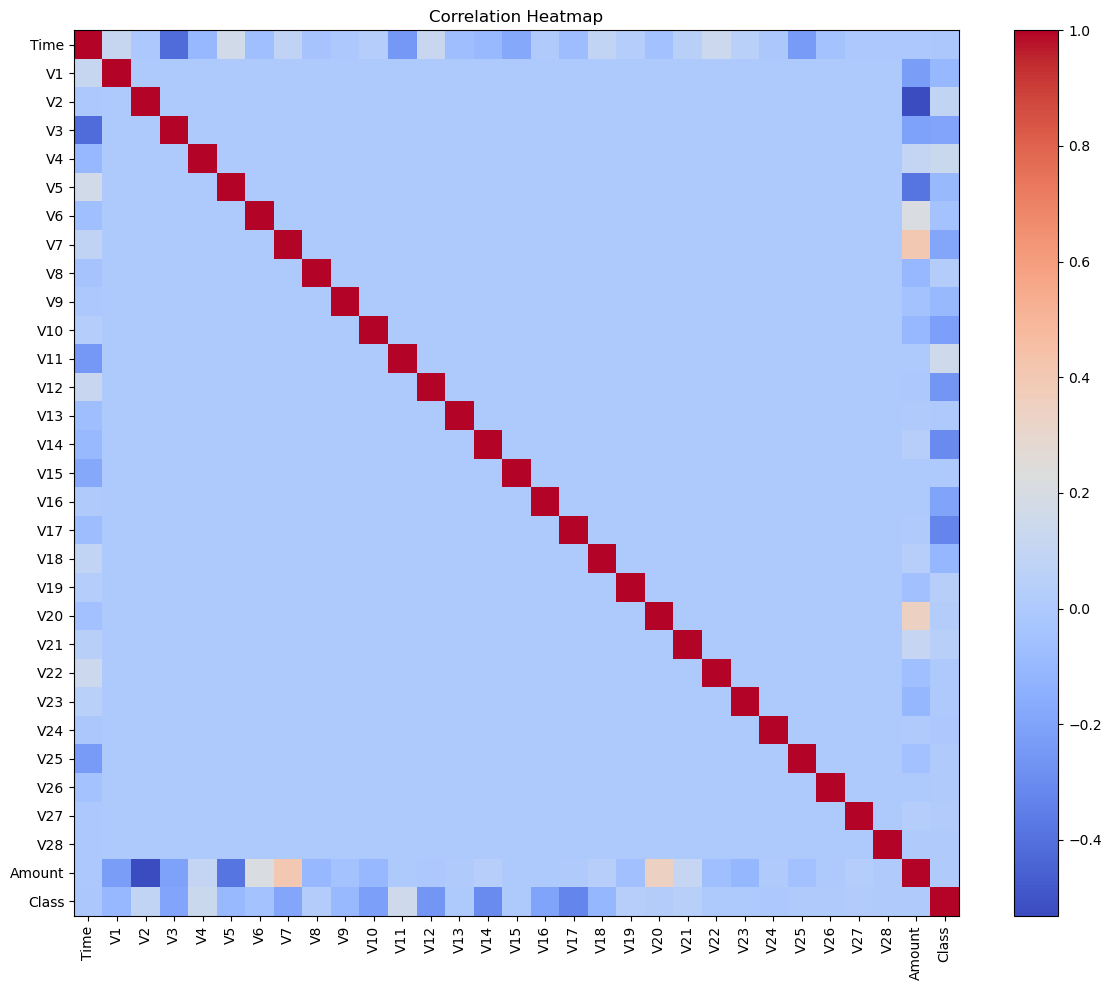

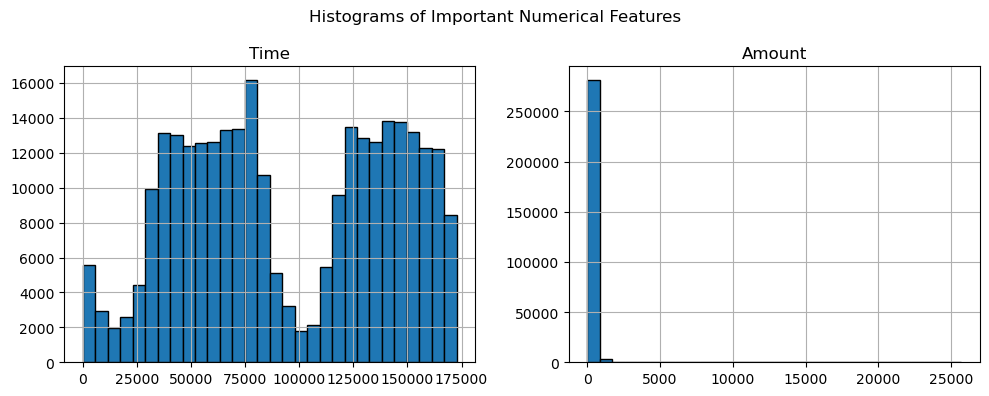

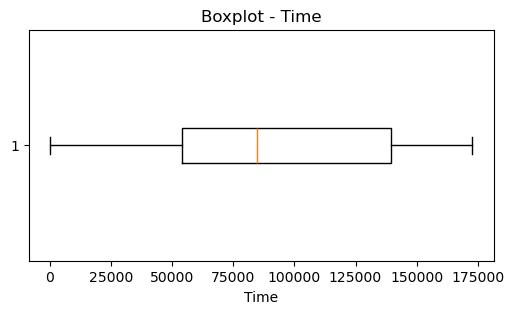

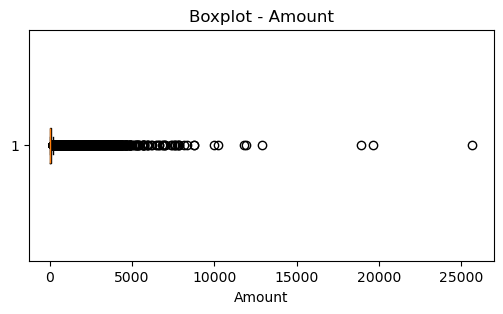

EDA Insight:
- Fraud class is usually much smaller than non-fraud class (class imbalance).
- Some numeric columns may contain outliers.
- Correlation helps identify related features for modeling discussion.


In [6]:
# ==========================
# SECTION 3: EXPLORATORY DATA ANALYSIS
# ==========================

print("Basic summary:")
print(df.describe(include="all"))

# Class distribution
class_counts = df["Class"].value_counts().sort_index()
print("Class distribution:", class_counts)

plt.figure(figsize=(6, 4))
bars = plt.bar(["Non-Fraud (0)", "Fraud (1)"], class_counts.values, color=["steelblue", "tomato"])
plt.title("Class Distribution")
plt.ylabel("Count")
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f"{int(height)}", ha="center", va="bottom")
plt.show()

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numerical columns:", numeric_cols)

# Correlation heatmap (matplotlib only)
corr = df[numeric_cols].corr()
plt.figure(figsize=(12, 10))
im = plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar(im)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Histograms for important columns
important_cols = [c for c in ["Time", "Amount"] if c in df.columns]
if len(important_cols) == 0:
    important_cols = numeric_cols[:4]

df[important_cols].hist(figsize=(10, 4), bins=30, edgecolor="black")
plt.suptitle("Histograms of Important Numerical Features")
plt.tight_layout()
plt.show()

# Boxplots for outlier inspection
for col in important_cols:
    plt.figure(figsize=(6, 3))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Boxplot - {col}")
    plt.xlabel(col)
    plt.show()

print("EDA Insight:")
print("- Fraud class is usually much smaller than non-fraud class (class imbalance).")
print("- Some numeric columns may contain outliers.")
print("- Correlation helps identify related features for modeling discussion.")


## Section 4: Data Preprocessing
Handles missing values, feature-target split, stratified train-test split, and scaling.


In [ ]:
# ==========================
# SECTION 4: DATA PREPROCESSING
# ==========================

# Median imputation for numeric columns
imputer = SimpleImputer(strategy="median")
df_imputed = df.copy()
df_imputed[numeric_cols] = imputer.fit_transform(df_imputed[numeric_cols])
X = df_imputed.drop(columns=["Class"])
y = df_imputed["Class"]

feature_names = X.columns.tolist()
# Train-test split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train_raw.shape, "Test shape:", X_test_raw.shape)
print("Train class distribution:", y_train.value_counts())
print("Test class distribution:", y_test.value_counts())

print("\nTrain-Test Split Completed")
print("X_train shape:", X_train_raw.shape)
print("X_test shape :", X_test_raw.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)



Train shape: (227845, 30) Test shape: (56962, 30)
Train class distribution: Class
0.0    227451
1.0       394
Name: count, dtype: int64
Test class distribution: Class
0.0    56864
1.0       98
Name: count, dtype: int64

Train-Test Split Completed
X_train shape: (227845, 30)
X_test shape : (56962, 30)
y_train shape: (227845,)
y_test shape : (56962,)


## Section 5: SMOTE Analysis
Applies SMOTE only to the training set to prevent leakage.


In [8]:
# ==========================
# SECTION 5: SMOTE ANALYSIS
# ==========================

# Apply SMOTE on training data only
smote = SMOTE(random_state=42)
X_train_smote_raw, y_train_smote = smote.fit_resample(X_train_raw, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_smote.value_counts())
print("Resampled train shape:", X_train_smote_raw.shape, y_train_smote.shape)

# Scale for Logistic Regression and ANN
scaler = StandardScaler()
X_train_smote_scaled = scaler.fit_transform(X_train_smote_raw)
X_test_scaled = scaler.transform(X_test_raw)

# Keep DataFrame versions for SHAP/LIME
X_train_smote_raw_df = X_train_smote_raw.copy()
X_test_raw_df = X_test_raw.copy()


Before SMOTE: Class
0.0    227451
1.0       394
Name: count, dtype: int64
After SMOTE: Class
0.0    227451
1.0    227451
Name: count, dtype: int64
Resampled train shape: (454902, 30) (454902,)


## Section 6: Model Building Overview


In [ ]:
# ==========================
# SECTION 6: MODEL BUILDING OVERVIEW (Utility functions)
# Logistic Regression: interpretable baseline.
# Random Forest: strong tabular non-linear model.
# ANN: captures complex patterns for performance comparison.
# ==========================

results = []
roc_data = {}

def evaluate_model(model_name, y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc = roc_auc_score(y_true, y_prob)

    print(f"{model_name} - Classification Report")
    print(classification_report(y_true, y_pred, digits=4))

 
    print(f"{model_name} Metrics:")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc:.4f}")

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc:.4f})")
    plt.plot([0, 1], [0, 1], "--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 4))
    plt.imshow(cm, cmap="Blues")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center", color="black")
    plt.xticks([0, 1], ["0", "1"])
    plt.yticks([0, 1], ["0", "1"])
    plt.tight_layout()
    plt.show()

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc_val = auc(fpr, tpr)
    roc_data[model_name] = (fpr, tpr, roc_auc_val)

    results.append({
        "Model Name": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "ROC-AUC": roc
    })



## Section 7: Logistic Regression


Logistic Regression - Classification Report
              precision    recall  f1-score   support

         0.0     0.9998    0.9900    0.9949     56864
         1.0     0.1341    0.8980    0.2334        98

    accuracy                         0.9899     56962
   macro avg     0.5670    0.9440    0.6142     56962
weighted avg     0.9983    0.9899    0.9936     56962

Logistic Regression Metrics:
Accuracy : 0.9899
Precision: 0.1341
Recall   : 0.8980
F1-Score : 0.2334
ROC-AUC  : 0.9765


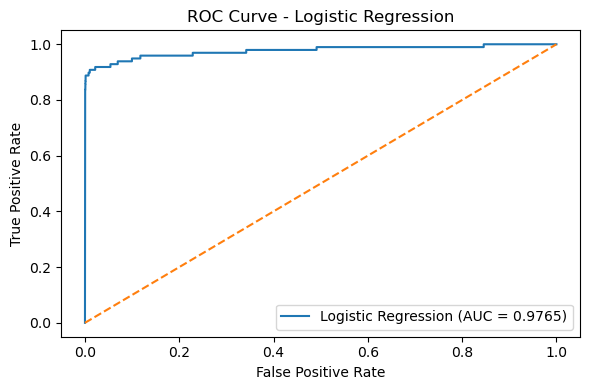

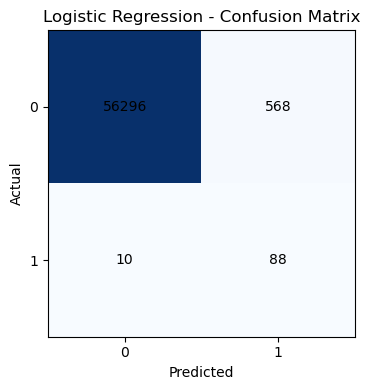

In [11]:
# ==========================
# SECTION 7: LOGISTIC REGRESSION MODEL
# ==========================

log_reg = LogisticRegression(random_state=42, max_iter=2000, class_weight="balanced")
log_reg.fit(X_train_smote_scaled, y_train_smote)

y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]
#threshold = 0.30  # change this value
y_pred_lr = log_reg.predict(X_test_scaled)
#y_pred_lr = (y_prob_lr >= threshold).astype(int)

evaluate_model("Logistic Regression", y_test, y_pred_lr, y_prob_lr)


## Section 8: Random Forest


Random Forest - Classification Report
              precision    recall  f1-score   support

         0.0     0.9998    0.9987    0.9993     56864
         1.0     0.5404    0.8878    0.6718        98

    accuracy                         0.9985     56962
   macro avg     0.7701    0.9432    0.8355     56962
weighted avg     0.9990    0.9985    0.9987     56962

Random Forest Metrics:
Accuracy : 0.9985
Precision: 0.5404
Recall   : 0.8878
F1-Score : 0.6718
ROC-AUC  : 0.9836


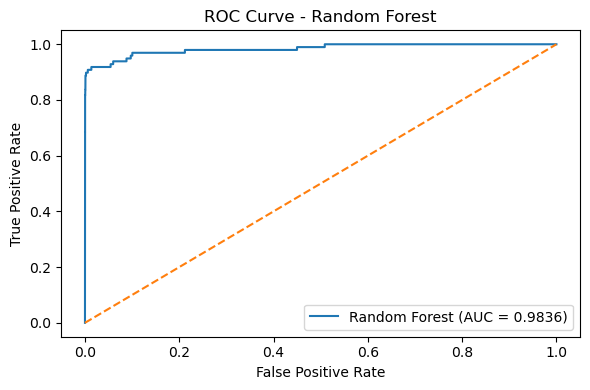

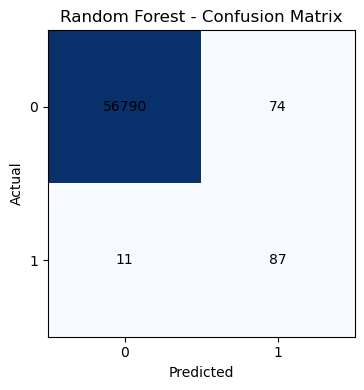

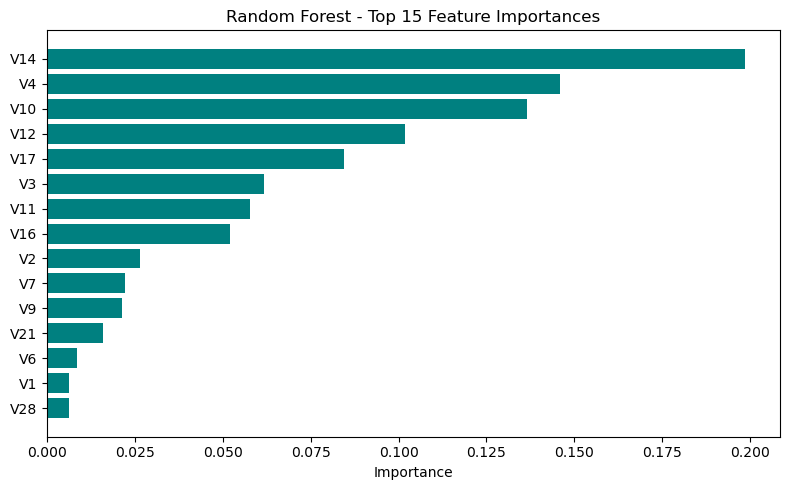

In [12]:
# ==========================
# SECTION 8: RANDOM FOREST MODEL
# ==========================

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    max_depth=10,
    class_weight="balanced",
    n_jobs=-1
)
rf_model.fit(X_train_smote_raw, y_train_smote)

y_pred_rf = rf_model.predict(X_test_raw)
y_prob_rf = rf_model.predict_proba(X_test_raw)[:, 1]

evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf)

# Feature importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:15]
top_features = [feature_names[i] for i in indices]
top_importances = importances[indices]

plt.figure(figsize=(8, 5))
plt.barh(range(len(top_features)), top_importances[::-1], color="teal")
plt.yticks(range(len(top_features)), top_features[::-1])
plt.xlabel("Importance")
plt.title("Random Forest - Top 15 Feature Importances")
plt.tight_layout()
plt.show()


## Section 9: Artificial Neural Network (ANN)


Epoch 1/30
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9732 - loss: 0.0783 - precision: 0.9781 - val_accuracy: 0.9828 - val_loss: 0.0392 - val_precision: 1.0000
Epoch 2/30
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9908 - loss: 0.0273 - precision: 0.9894 - val_accuracy: 0.9937 - val_loss: 0.0169 - val_precision: 1.0000
Epoch 3/30
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9945 - loss: 0.0174 - precision: 0.9922 - val_accuracy: 0.9981 - val_loss: 0.0087 - val_precision: 1.0000
Epoch 4/30
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9959 - loss: 0.0129 - precision: 0.9938 - val_accuracy: 0.9988 - val_loss: 0.0063 - val_precision: 1.0000
Epoch 5/30
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9968 - loss: 0.0104 - precision: 0.9947 - val_accuracy: 0.9994 - val_loss: 0.0039 - val_precision: 1.0000
Epoch 6/30
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9973 - loss: 0.0087 - precision: 0.9954 - val_accuracy: 0.9993

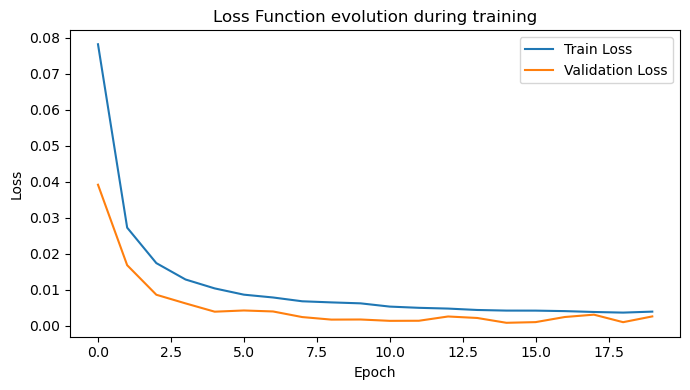

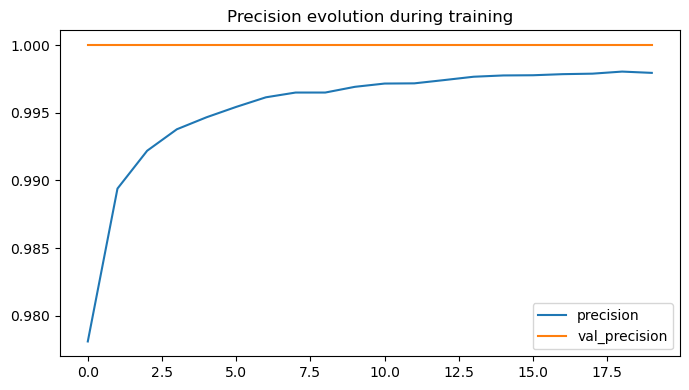

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1s 640us/step
ANN - Classification Report
              precision    recall  f1-score   support

         0.0     0.9998    0.9991    0.9994     56864
         1.0     0.6087    0.8571    0.7119        98

    accuracy                         0.9988     56962
   macro avg     0.8042    0.9281    0.8556     56962
weighted avg     0.9991    0.9988    0.9989     56962

ANN Metrics:
Accuracy : 0.9988
Precision: 0.6087
Recall   : 0.8571
F1-Score : 0.7119
ROC-AUC  : 0.9706


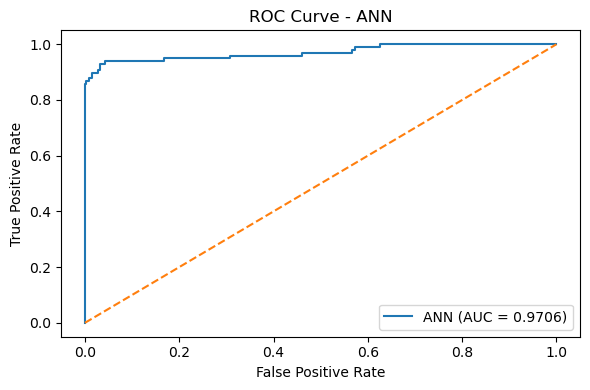

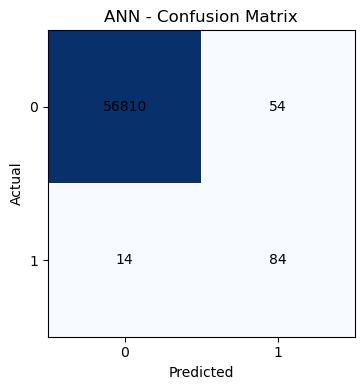

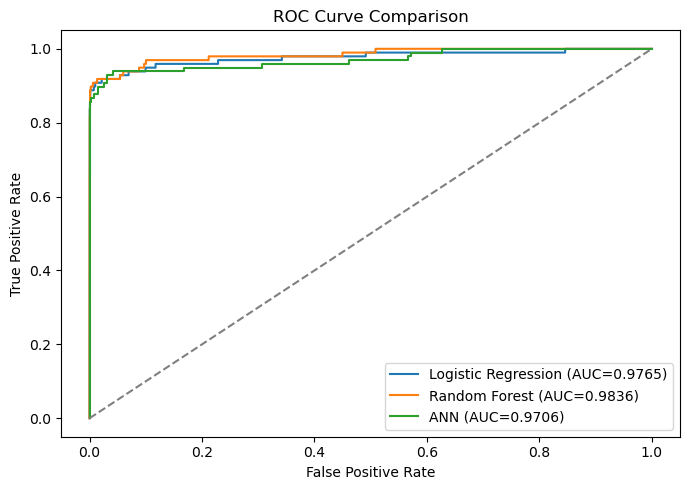

In [26]:
# ==========================
# SECTION 9: ARTIFICIAL NEURAL NETWORK (ANN)
# ==========================

ann_model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_smote_scaled.shape[1],)),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

ann_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy", "precision"])

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = ann_model.fit(
    X_train_smote_scaled, y_train_smote,
    validation_split=0.2,
    epochs=30,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss Function evolution during training")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history.history["precision"], label="precision")
plt.plot(history.history["val_precision"], label="val_precision")
plt.title("Precision evolution during training")
plt.legend()
plt.tight_layout()
plt.show()

y_prob_ann = ann_model.predict(X_test_scaled).ravel()
y_pred_ann = (y_prob_ann >= 0.5).astype(int)

evaluate_model("ANN", y_test, y_pred_ann, y_prob_ann)

plt.figure(figsize=(7, 5))
for model_name, (fpr, tpr, roc_auc_val) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={roc_auc_val:.4f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()


Using 2000 rows for SHAP out of 56962 test rows.
SHAP computed in 44.26 sec


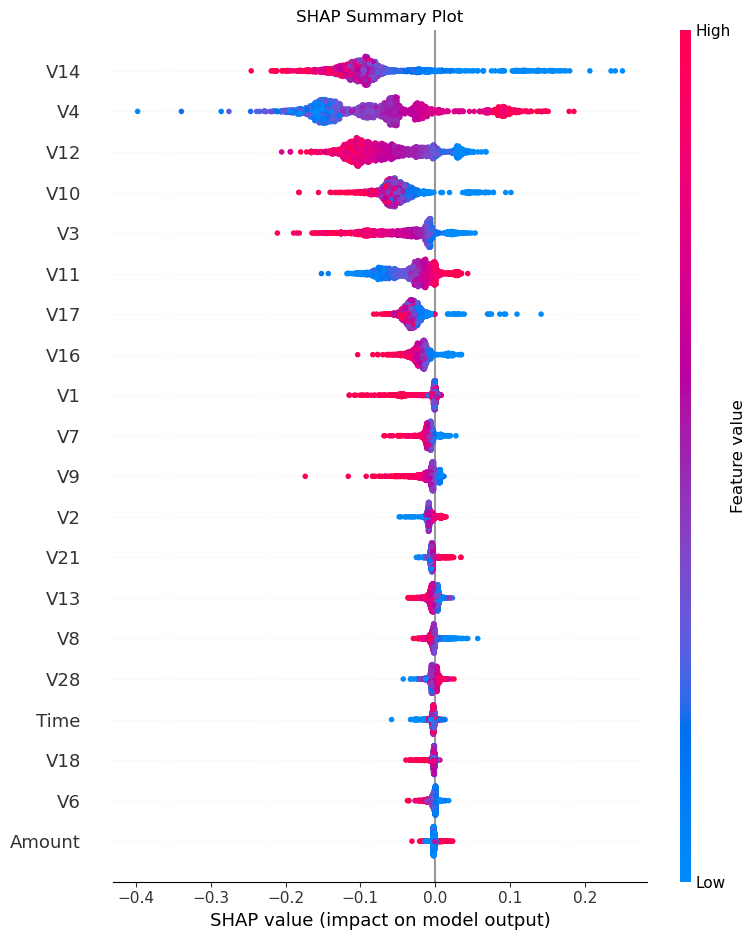

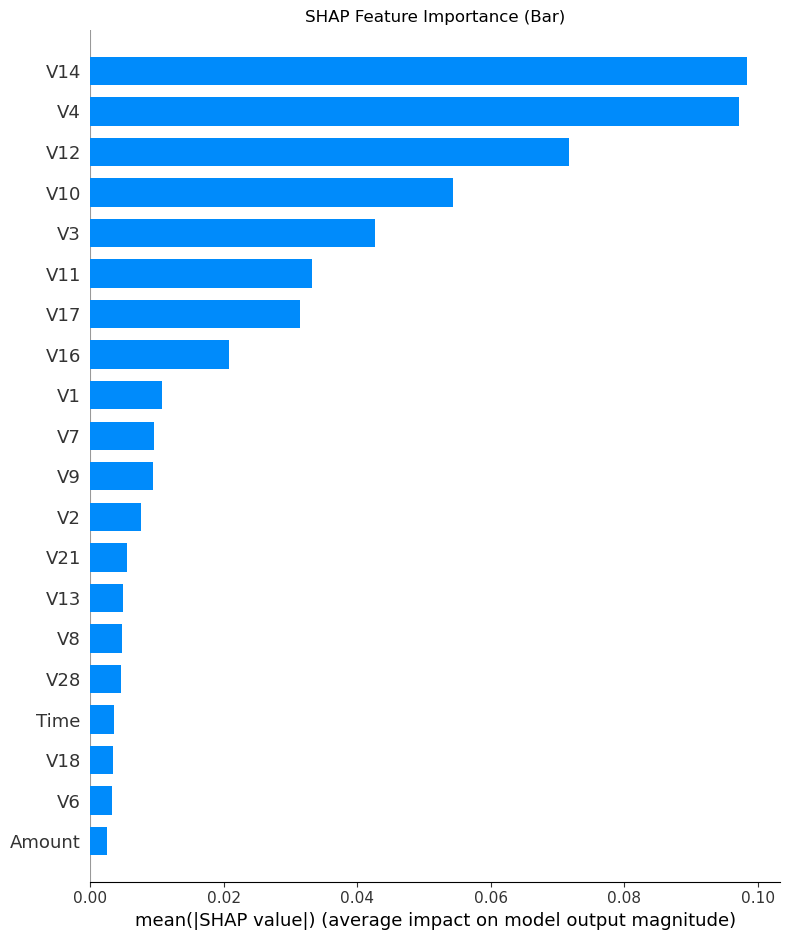

Top SHAP feature: V14


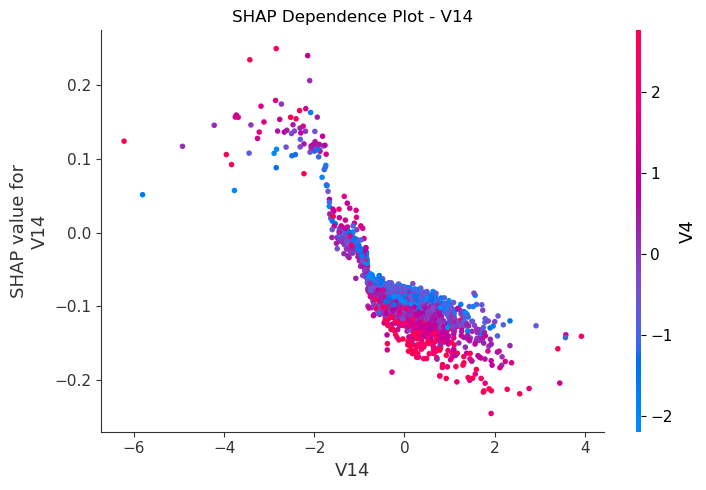

Saved SHAP force plot 1: shap_outputs/force_plot_sample_1.html
Saved SHAP force plot 2: shap_outputs/force_plot_sample_2.html
Saved SHAP force plot 3: shap_outputs/force_plot_sample_3.html


In [17]:
# ==========================
# SECTION 10: SHAP EXPLAINABILITY MODULE (FAST)
# ==========================
import time
shap.initjs()

# 1) Use only a subset of test data for SHAP plots (much faster)
MAX_SHAP_SAMPLES = 2000   # try 1000 if still slow
if len(X_test_raw_df) > MAX_SHAP_SAMPLES:
    X_shap = X_test_raw_df.sample(n=MAX_SHAP_SAMPLES, random_state=RANDOM_STATE)
else:
    X_shap = X_test_raw_df.copy()

print(f"Using {len(X_shap)} rows for SHAP out of {len(X_test_raw_df)} test rows.")

# 2) TreeExplainer + additivity check off (faster)
explainer = shap.TreeExplainer(rf_model)
t0 = time.time()
shap_values = explainer.shap_values(X_shap, check_additivity=False)
print(f"SHAP computed in {time.time() - t0:.2f} sec")

# Handle SHAP output format
if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]
    expected_value_pos = explainer.expected_value[1]
else:
    # Some SHAP versions return (n_samples, n_features, n_classes)
    if hasattr(shap_values, "ndim") and shap_values.ndim == 3:
        shap_values_pos = shap_values[:, :, 1]
        expected_value_pos = explainer.expected_value[1]
    else:
        shap_values_pos = shap_values
        expected_value_pos = explainer.expected_value

# SHAP summary plot
shap.summary_plot(shap_values_pos, X_shap, show=False)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.show()

# SHAP importance bar
shap.summary_plot(shap_values_pos, X_shap, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Bar)")
plt.tight_layout()
plt.show()

# SHAP dependence plot (top feature)
mean_abs_shap = np.abs(shap_values_pos).mean(axis=0)
top_feat_idx = np.argmax(mean_abs_shap)
top_feat_name = X_shap.columns[top_feat_idx]
print(f"Top SHAP feature: {top_feat_name}")

shap.dependence_plot(top_feat_name, shap_values_pos, X_shap, show=False)
plt.title(f"SHAP Dependence Plot - {top_feat_name}")
plt.tight_layout()
plt.show()

# Force plots for 3 fraud samples from X_shap index
fraud_candidates = y_test.loc[X_shap.index]
fraud_indices = np.where(fraud_candidates.values == 1)[0]
sample_indices = fraud_indices[:3] if len(fraud_indices) >= 3 else np.arange(min(3, len(X_shap)))

os.makedirs("shap_outputs", exist_ok=True)
for i, idx in enumerate(sample_indices, start=1):
    force_plot = shap.force_plot(
        expected_value_pos,
        shap_values_pos[idx],
        X_shap.iloc[idx],
        matplotlib=False
    )
    html_path = f"shap_outputs/force_plot_sample_{i}.html"
    shap.save_html(html_path, force_plot)
    print(f"Saved SHAP force plot {i}: {html_path}")


## Section 10: SHAP Explainability
Generates summary, feature-importance, dependence, and force plots (3 samples).


X_test shape: (56962, 30)
SHAP shape: (56962, 30)


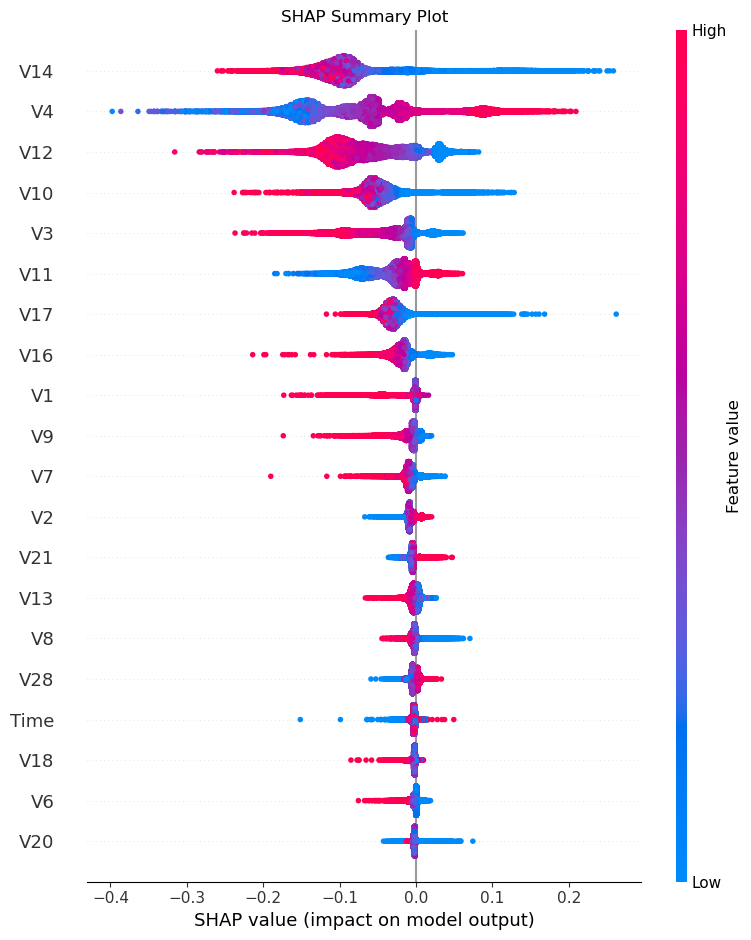

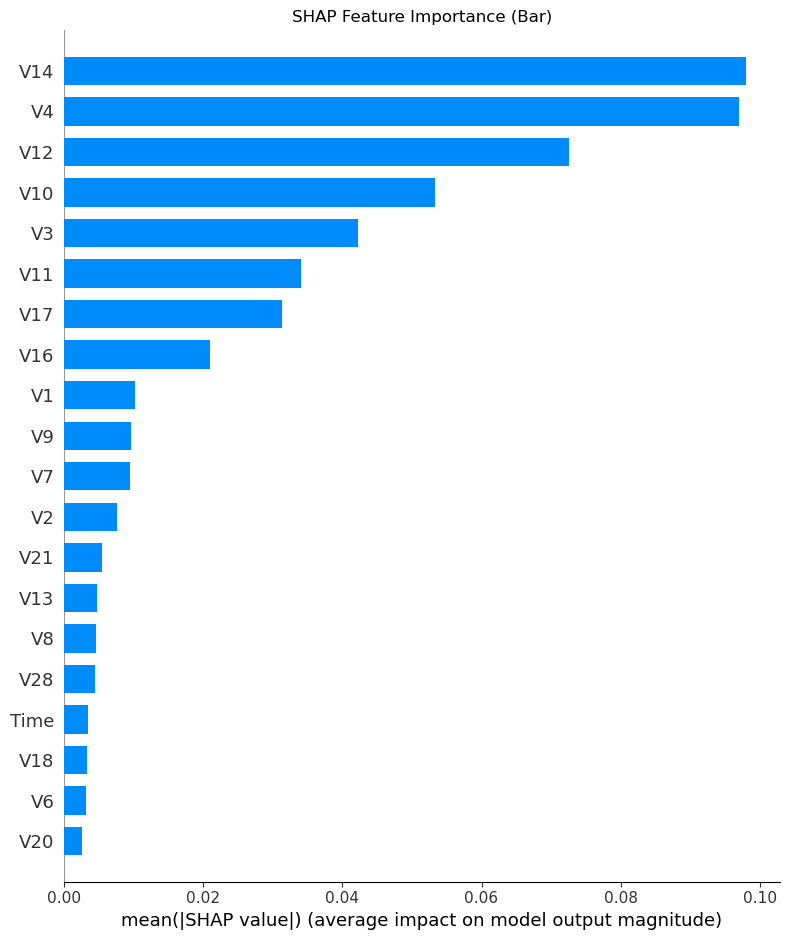

Top SHAP feature selected for dependence plot: V14


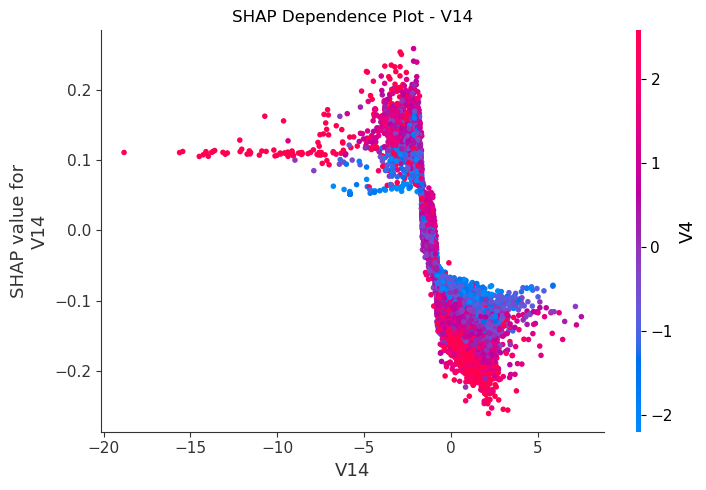

Saved SHAP force plot 1 to: shap_outputs/force_plot_sample_1.html
Saved SHAP force plot 2 to: shap_outputs/force_plot_sample_2.html
Saved SHAP force plot 3 to: shap_outputs/force_plot_sample_3.html


In [ ]:
# ==========================
# SECTION 10: SHAP EXPLAINABILITY MODULE (FIXED)
# ==========================
# We use Random Forest for SHAP because tree-based SHAP is stable and fast for tabular data.
# If you want SHAP for ANN, use KernelExplainer (slower).

import os
import numpy as np
import shap
import matplotlib.pyplot as plt

shap.initjs()

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_raw_df)

# ---- Robust shape handling for different SHAP versions ----
if isinstance(shap_values, list):
    # Old style: list of arrays per class
    shap_values_pos = shap_values[1]   # binary classification => index 1 for fraud class
    expected_value_pos = explainer.expected_value[1]
else:
     # newer SHAP may return array
    shap_values = np.array(shap_values)

    if shap_values.ndim == 3:
        # New style: (n_samples, n_features, n_classes)
        shap_values_pos = shap_values[:, :, 1]   # fraud class
        ev = np.array(explainer.expected_value)
        expected_value_pos = ev[1] if ev.ndim > 0 else float(ev)
    elif shap_values.ndim == 2:
        # Already (n_samples, n_features)
        shap_values_pos = shap_values
        ev = np.array(explainer.expected_value)
        expected_value_pos = ev[1] if ev.ndim > 0 and len(ev) > 1 else float(ev)
    else:
        raise ValueError(f"Unexpected SHAP shape: {shap_values.shape}")

print("X_test shape:", X_test_raw_df.shape)
print("SHAP shape:", shap_values_pos.shape)

# Summary plot (dot)
shap.summary_plot(shap_values_pos, X_test_raw_df, show=False)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.show()

# Feature-importance plot (bar)
shap.summary_plot(shap_values_pos, X_test_raw_df, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Bar)")
plt.tight_layout()
plt.show()

# Dependence plot for top feature
mean_abs_shap = np.abs(shap_values_pos).mean(axis=0)
top_feat_idx = np.argmax(mean_abs_shap)
top_feat_name = X_test_raw_df.columns[top_feat_idx]
print(f"Top SHAP feature selected for dependence plot: {top_feat_name}")

shap.dependence_plot(top_feat_name, shap_values_pos, X_test_raw_df, show=False)
plt.title(f"SHAP Dependence Plot - {top_feat_name}")
plt.tight_layout()
plt.show()

# Force plots for 3 samples
# SHAP force plots for at least 3 sample transactions
# Prefer fraud cases in test set if available
fraud_indices = np.where(y_test.values == 1)[0]
sample_indices = fraud_indices[:3] if len(fraud_indices) >= 3 else np.arange(min(3, len(X_test_raw_df)))

os.makedirs("shap_outputs", exist_ok=True)
for i, idx in enumerate(sample_indices, start=1):
    force_plot = shap.force_plot(
        expected_value_pos,
        shap_values_pos[idx],
        X_test_raw_df.iloc[idx],
        matplotlib=False
    )
    html_path = f"shap_outputs/force_plot_sample_{i}.html"
    shap.save_html(html_path, force_plot)
    print(f"Saved SHAP force plot {i} to: {html_path}")


## Section 11: LIME Explainability
Explains at least 3 transactions and compares local explanations with SHAP.


Saved LIME explanation 1 to: lime_outputs/lime_explanation_sample_1.html


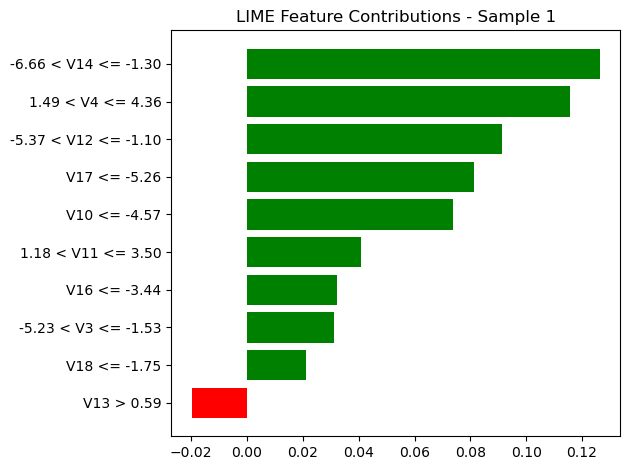

Saved LIME explanation 2 to: lime_outputs/lime_explanation_sample_2.html


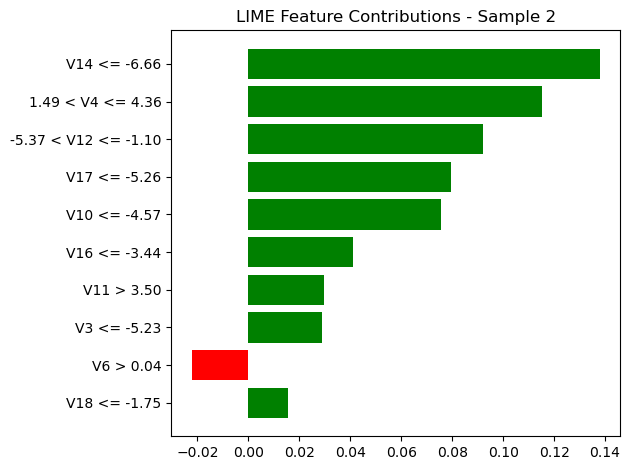

Saved LIME explanation 3 to: lime_outputs/lime_explanation_sample_3.html


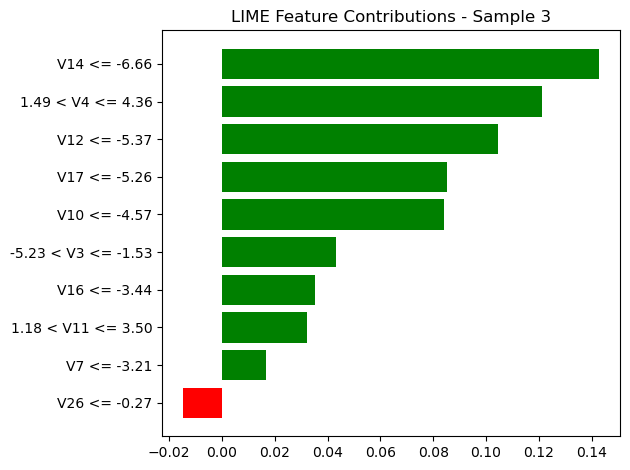

SHAP vs LIME Comparison (Top Features Overlap):
Sample 1:
  SHAP top features: ['V14', 'V17', 'V10', 'V4', 'V12']
  LIME top features: ['-6.66 < V14 <= -1.30', '1.49 < V4 <= 4.36', '-5.37 < V12 <= -1.10', 'V17 <= -5.26', 'V10 <= -4.57']
  Overlap: No direct textual overlap (formatting differs).
Sample 2:
  SHAP top features: ['V14', 'V17', 'V10', 'V4', 'V12']
  LIME top features: ['V14 <= -6.66', '1.49 < V4 <= 4.36', '-5.37 < V12 <= -1.10', 'V17 <= -5.26', 'V10 <= -4.57']
  Overlap: No direct textual overlap (formatting differs).
Sample 3:
  SHAP top features: ['V14', 'V17', 'V10', 'V4', 'V12']
  LIME top features: ['V14 <= -6.66', '1.49 < V4 <= 4.36', 'V12 <= -5.37', 'V17 <= -5.26', 'V10 <= -4.57']
  Overlap: No direct textual overlap (formatting differs).


In [23]:
# ==========================
# SECTION 11: LIME EXPLAINABILITY MODULE
# ==========================

lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train_smote_raw_df),
    feature_names=feature_names,
    class_names=["Non-Fraud", "Fraud"],
    mode="classification",
    random_state=RANDOM_STATE
)

os.makedirs("lime_outputs", exist_ok=True)

lime_top_features = {}
shap_top_features = {}

for i, idx in enumerate(sample_indices, start=1):
    instance = X_test_raw_df.iloc[idx].values
    exp = lime_explainer.explain_instance(
        data_row=instance,
        predict_fn=rf_model.predict_proba,
        num_features=10
    )

    lime_html_path = f"lime_outputs/lime_explanation_sample_{i}.html"
    exp.save_to_file(lime_html_path)
    print(f"Saved LIME explanation {i} to: {lime_html_path}")

    fig = exp.as_pyplot_figure()
    plt.title(f"LIME Feature Contributions - Sample {i}")
    plt.tight_layout()
    plt.show()

    lime_feats = [item[0] for item in exp.as_list()[:5]]
    lime_top_features[i] = lime_feats

    shap_idx = np.argsort(np.abs(shap_values_pos[idx]))[::-1][:5]
    shap_feats = [X_test_raw_df.columns[j] for j in shap_idx]
    shap_top_features[i] = shap_feats

print("SHAP vs LIME Comparison (Top Features Overlap):")
for i in range(1, len(sample_indices) + 1):
    overlap = set(lime_top_features[i]).intersection(set(shap_top_features[i]))
    print(f"Sample {i}:")
    print("  SHAP top features:", shap_top_features[i])
    print("  LIME top features:", lime_top_features[i])
    print("  Overlap:", list(overlap) if overlap else "No direct textual overlap (formatting differs).")


## Section 12: Model Comparison
Creates a comparison table and selects best model based on ROC-AUC and Recall.


Model Comparison Table:
            Model Name  Accuracy  Precision    Recall  F1-score   ROC-AUC
0  Logistic Regression  0.989853   0.134146  0.897959  0.233422  0.976482
1        Random Forest  0.998508   0.540373  0.887755  0.671815  0.983626
2                  ANN  0.998806   0.608696  0.857143  0.711864  0.970624
Best model based on ROC-AUC and Recall: Random Forest


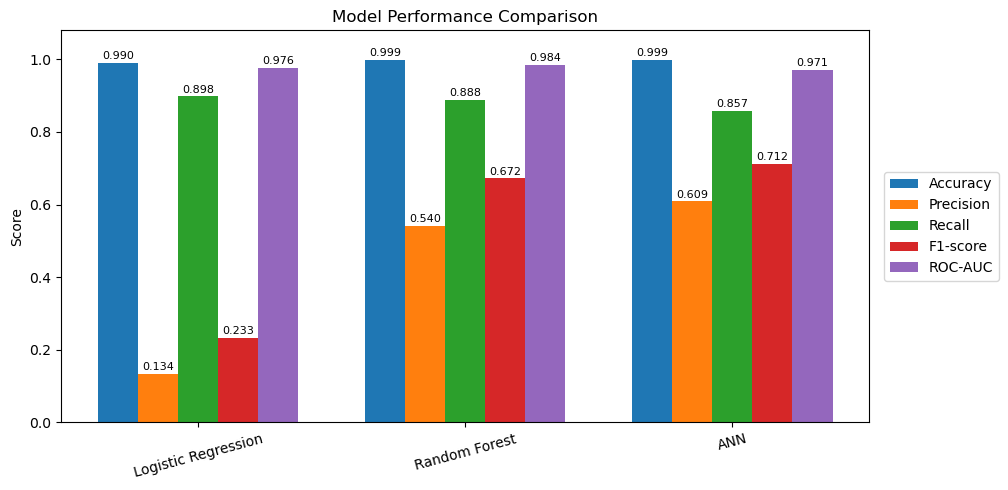

In [34]:
# ==========================
# SECTION 12: MODEL COMPARISON (FIXED)
# ==========================

# 1) Build table from results list
results_df = pd.DataFrame(results)

# 2) Keep only the latest row per model (prevents duplicates when cells are rerun)
results_df = results_df.drop_duplicates(subset=["Model Name"], keep="last")

# Optional: enforce model order
model_order = ["Logistic Regression", "Random Forest", "ANN"]
results_df["Model Name"] = pd.Categorical(results_df["Model Name"], categories=model_order, ordered=True)
results_df = results_df.sort_values("Model Name").reset_index(drop=True)

print("Model Comparison Table:")
print(results_df)

# 3) Best model by ROC-AUC then Recall
best_model = results_df.sort_values(by=["ROC-AUC", "Recall"], ascending=False).iloc[0]["Model Name"]
print(f"Best model based on ROC-AUC and Recall: {best_model}")

# 4) Plot grouped bars
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
x = np.arange(len(results_df["Model Name"]))
bar_width = 0.15

plt.figure(figsize=(12, 5))
for i, metric in enumerate(metrics_to_plot):
    bars = plt.bar(x + i * bar_width, results_df[metric], width=bar_width, label=metric)
    # value labels
    for b in bars:
        h = b.get_height()
        plt.text(b.get_x() + b.get_width()/2, h + 0.005, f"{h:.3f}", ha="center", va="bottom", fontsize=8)

plt.xticks(x + bar_width * 2, results_df["Model Name"], rotation=15)
plt.ylim(0, 1.08)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
# plt.legend()
# plt.tight_layout()
plt.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=True)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


In [31]:
# ==========================
# SECTION 13: FINAL INTERPRETATION
# ==========================

print("FINAL INTERPRETATION")
print("")

# Safety check
if "results_df" not in globals() or results_df.empty:
    print("No model comparison data found. Run Section 12 first.")
else:
    # Best model by ROC-AUC first, then Recall
    best_row = results_df.sort_values(by=["ROC-AUC", "Recall"], ascending=False).iloc[0]
    best_model = best_row["Model Name"]

    print(f"Best model based on ROC-AUC and Recall: {best_model}")
    print("")

    # Print each model summary line
    for _, row in results_df.iterrows():
        print(
            f"{row['Model Name']}: "
            f"Accuracy={row['Accuracy']:.4f}, "
            f"Precision={row['Precision']:.4f}, "
            f"Recall={row['Recall']:.4f}, "
            f"F1-score={row['F1-score']:.4f}, "
            f"ROC-AUC={row['ROC-AUC']:.4f}"
        )

    print("\nInterpretation Notes:")
    print("- Recall is critical in fraud detection because higher recall means fewer fraud cases are missed.")
    print("- Precision is also important because higher precision means fewer genuine customers are wrongly flagged.")
    print("- F1-score balances precision and recall, so it is useful for imbalanced fraud datasets.")
    print("- ROC-AUC evaluates discrimination across all thresholds, not just one fixed threshold.")
    print("- Accuracy alone can be misleading in highly imbalanced datasets.")

    # Optional model-specific comment
    print("\nPractical Conclusion:")
    if best_model == "Random Forest":
        print("- Random Forest provides the strongest operational balance for this run.")
    elif best_model == "ANN":
        print("- ANN provides strong predictive performance for this run.")
    else:
        print("- Logistic Regression provides high sensitivity but may require threshold tuning.")

    print("- SMOTE improved minority-class learning by balancing the training set only, helping avoid data leakage.")
    print("- SHAP (global + local) and LIME (transaction-level) improved interpretability and trust.")


FINAL INTERPRETATION

Best model based on ROC-AUC and Recall: Random Forest

Logistic Regression: Accuracy=0.9899, Precision=0.1341, Recall=0.8980, F1-score=0.2334, ROC-AUC=0.9765
Random Forest: Accuracy=0.9985, Precision=0.5404, Recall=0.8878, F1-score=0.6718, ROC-AUC=0.9836
ANN: Accuracy=0.9988, Precision=0.6087, Recall=0.8571, F1-score=0.7119, ROC-AUC=0.9706

Interpretation Notes:
- Recall is critical in fraud detection because higher recall means fewer fraud cases are missed.
- Precision is also important because higher precision means fewer genuine customers are wrongly flagged.
- F1-score balances precision and recall, so it is useful for imbalanced fraud datasets.
- ROC-AUC evaluates discrimination across all thresholds, not just one fixed threshold.
- Accuracy alone can be misleading in highly imbalanced datasets.

Practical Conclusion:
- Random Forest provides the strongest operational balance for this run.
- SMOTE improved minority-class learning by balancing the training set